In [115]:
#Cardiotocography

In [116]:
# Installing Libraries 

!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install xlrd


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [194]:
# Import the libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import matplotlib
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score




In [118]:
# Download Dataset from downloaded file from UCI Machine Learning Repository

df = pd.read_excel('/Users/daanishkhurshid/Atomcamp /ml_project/Cardiotocography/CTG.xls', sheet_name='Raw Data')
df.head(10)

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,0.0,0.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
5,Fmcs_1.txt,1996-05-03,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,0.0,0.0,0.0,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
6,Fmcs_2.txt,1996-05-03,CTG0006.txt,0.0,953.0,134.0,134.0,1.0,0.0,10.0,26.0,5.9,0.0,0.0,9.0,0.0,2.0,0.0,150.0,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
7,Fmcs_2.txt,1996-05-03,CTG0007.txt,240.0,953.0,134.0,134.0,1.0,0.0,9.0,29.0,6.3,0.0,0.0,6.0,0.0,2.0,0.0,150.0,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
8,Hasc_1.txt,1995-02-22,CTG0008.txt,62.0,679.0,122.0,122.0,0.0,0.0,0.0,83.0,0.5,6.0,15.6,0.0,0.0,0.0,0.0,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
9,Hasc_1.txt,1995-02-22,CTG0009.txt,120.0,779.0,122.0,122.0,0.0,0.0,1.0,84.0,0.5,5.0,13.6,0.0,0.0,0.0,0.0,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0


In [119]:
# Rename df to work on

ctg = df

ctg.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,0.0,0.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


In [120]:
# Get Shape of the dataset
ctg.shape

(2130, 40)

In [121]:
# Get info on the dataset

ctg.info()

<class 'pandas.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   FileName  2126 non-null   str           
 1   Date      2126 non-null   datetime64[us]
 2   SegFile   2126 non-null   str           
 3   b         2126 non-null   float64       
 4   e         2126 non-null   float64       
 5   LBE       2126 non-null   float64       
 6   LB        2126 non-null   float64       
 7   AC        2126 non-null   float64       
 8   FM        2127 non-null   float64       
 9   UC        2127 non-null   float64       
 10  ASTV      2127 non-null   float64       
 11  MSTV      2127 non-null   float64       
 12  ALTV      2127 non-null   float64       
 13  MLTV      2127 non-null   float64       
 14  DL        2128 non-null   float64       
 15  DS        2128 non-null   float64       
 16  DP        2128 non-null   float64       
 17  DR        2128 non-null  

In [122]:
# columns that need to removed, 'FileName','Date','SegFile','b','c'
# file names are not required as they were used while taking the test and stored locally
# Date is the date of the test and as no use in the training data
# Segfile again is a local file for when the test was taking place
# 'b' and 'e' are the start and end of the test which again are not required

ctg = ctg.drop(columns=['FileName','Date','SegFile','b','e'])
ctg.head()

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,0.0,0.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


In [123]:
# LBE column is also removed as its a value assigned by a medical expert

ctg = ctg.drop(columns=['LBE'])
ctg.head()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,0.0,0.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


In [124]:
# Remove the classification columns that are not required for the analysis,
# 'A','B','C','D','E','AD','DE''LD','FS','SUSP','CLASS',
# These columns are assigned by medical experts and not data required by the sensors
# NSP is our target variable, which is the classification of the test

ctg = ctg.drop(columns=['A','B','C','D','E','AD','DE','LD','DR','FS','SUSP','CLASS'])

In [125]:
ctg.info()

<class 'pandas.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2127 non-null   float64
 3   UC        2127 non-null   float64
 4   ASTV      2127 non-null   float64
 5   MSTV      2127 non-null   float64
 6   ALTV      2127 non-null   float64
 7   MLTV      2127 non-null   float64
 8   DL        2128 non-null   float64
 9   DS        2128 non-null   float64
 10  DP        2128 non-null   float64
 11  Width     2126 non-null   float64
 12  Min       2126 non-null   float64
 13  Max       2126 non-null   float64
 14  Nmax      2126 non-null   float64
 15  Nzeros    2126 non-null   float64
 16  Mode      2126 non-null   float64
 17  Mean      2126 non-null   float64
 18  Median    2126 non-null   float64
 19  Variance  2126 non-null   float64
 20  Tendency  2126 non-null   float64
 21  NS

In [126]:
ctg.shape

(2130, 22)

In [127]:
# This is to show all columns
pd.set_option('display.max_columns', None)

ctg.head()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,0.0,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
2,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,0.0,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
3,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,0.0,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
4,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,0.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0


In [128]:
ctg.describe()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2126.000000,2126.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2128.000000,2128.000000,2128.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,2.722484,7.503056,3.669017,47.008933,1.335449,9.884814,8.207616,1.576128,0.003759,0.127820,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,3.560850,39.030452,2.877148,17.210648,0.891543,18.476534,5.701926,2.517794,0.061213,0.471687,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,0.000000,4.600000,0.000000,0.000000,0.000000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,0.000000,7.400000,0.000000,0.000000,0.000000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,11.000000,10.800000,3.000000,0.000000,0.000000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,91.000000,50.700000,16.000000,1.000000,4.000000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [129]:
# Searching for missing values
ctg.isnull().sum()

LB          4
AC          4
FM          3
UC          3
ASTV        3
MSTV        3
ALTV        3
MLTV        3
DL          2
DS          2
DP          2
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
NSP         4
dtype: int64

In [130]:
# Calculate the percentage of missing values per column
missing_percent = (ctg.isnull().sum() / len(df)) * 100

print(missing_percent)


LB          0.187793
AC          0.187793
FM          0.140845
UC          0.140845
ASTV        0.140845
MSTV        0.140845
ALTV        0.140845
MLTV        0.140845
DL          0.093897
DS          0.093897
DP          0.093897
Width       0.187793
Min         0.187793
Max         0.187793
Nmax        0.187793
Nzeros      0.187793
Mode        0.187793
Mean        0.187793
Median      0.187793
Variance    0.187793
Tendency    0.187793
NSP         0.187793
dtype: float64


In [131]:
# As the missing cells are less than 1% we can just drop these rather than
# trying to impute them

# Drops any row that contains a missing value (NaN)
ctg = ctg.dropna(axis=0)         # as axis=0, the rows are dropped
ctg.isnull().sum()


LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
DL          0
DS          0
DP          0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
NSP         0
dtype: int64

In [132]:
ctg.shape

(2126, 22)

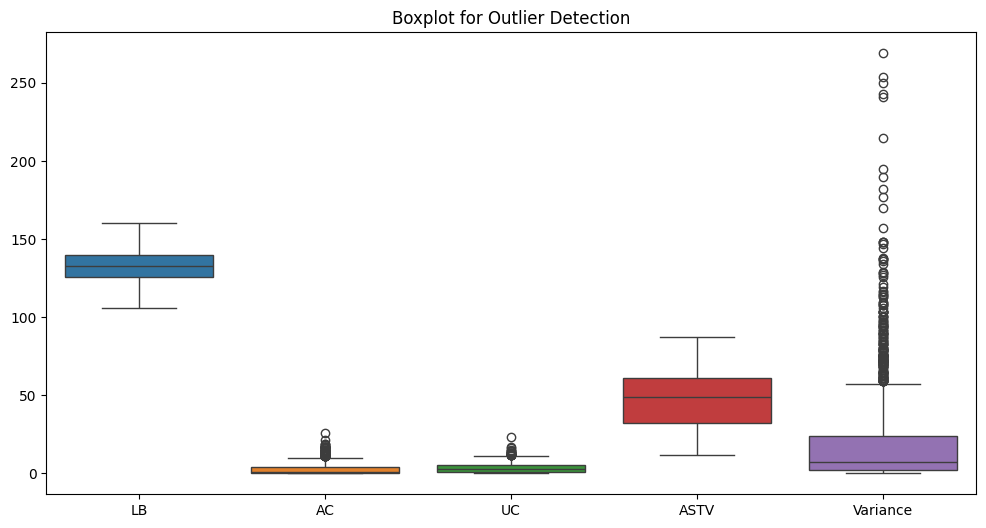

In [133]:
# Select a few key clinical features to check for outliers
cols_to_plot = ['LB', 'AC', 'UC', 'ASTV', 'Variance']

plt.figure(figsize=(12, 6))
sns.boxplot(data=ctg[cols_to_plot])
plt.title('Boxplot for Outlier Detection')
plt.show()


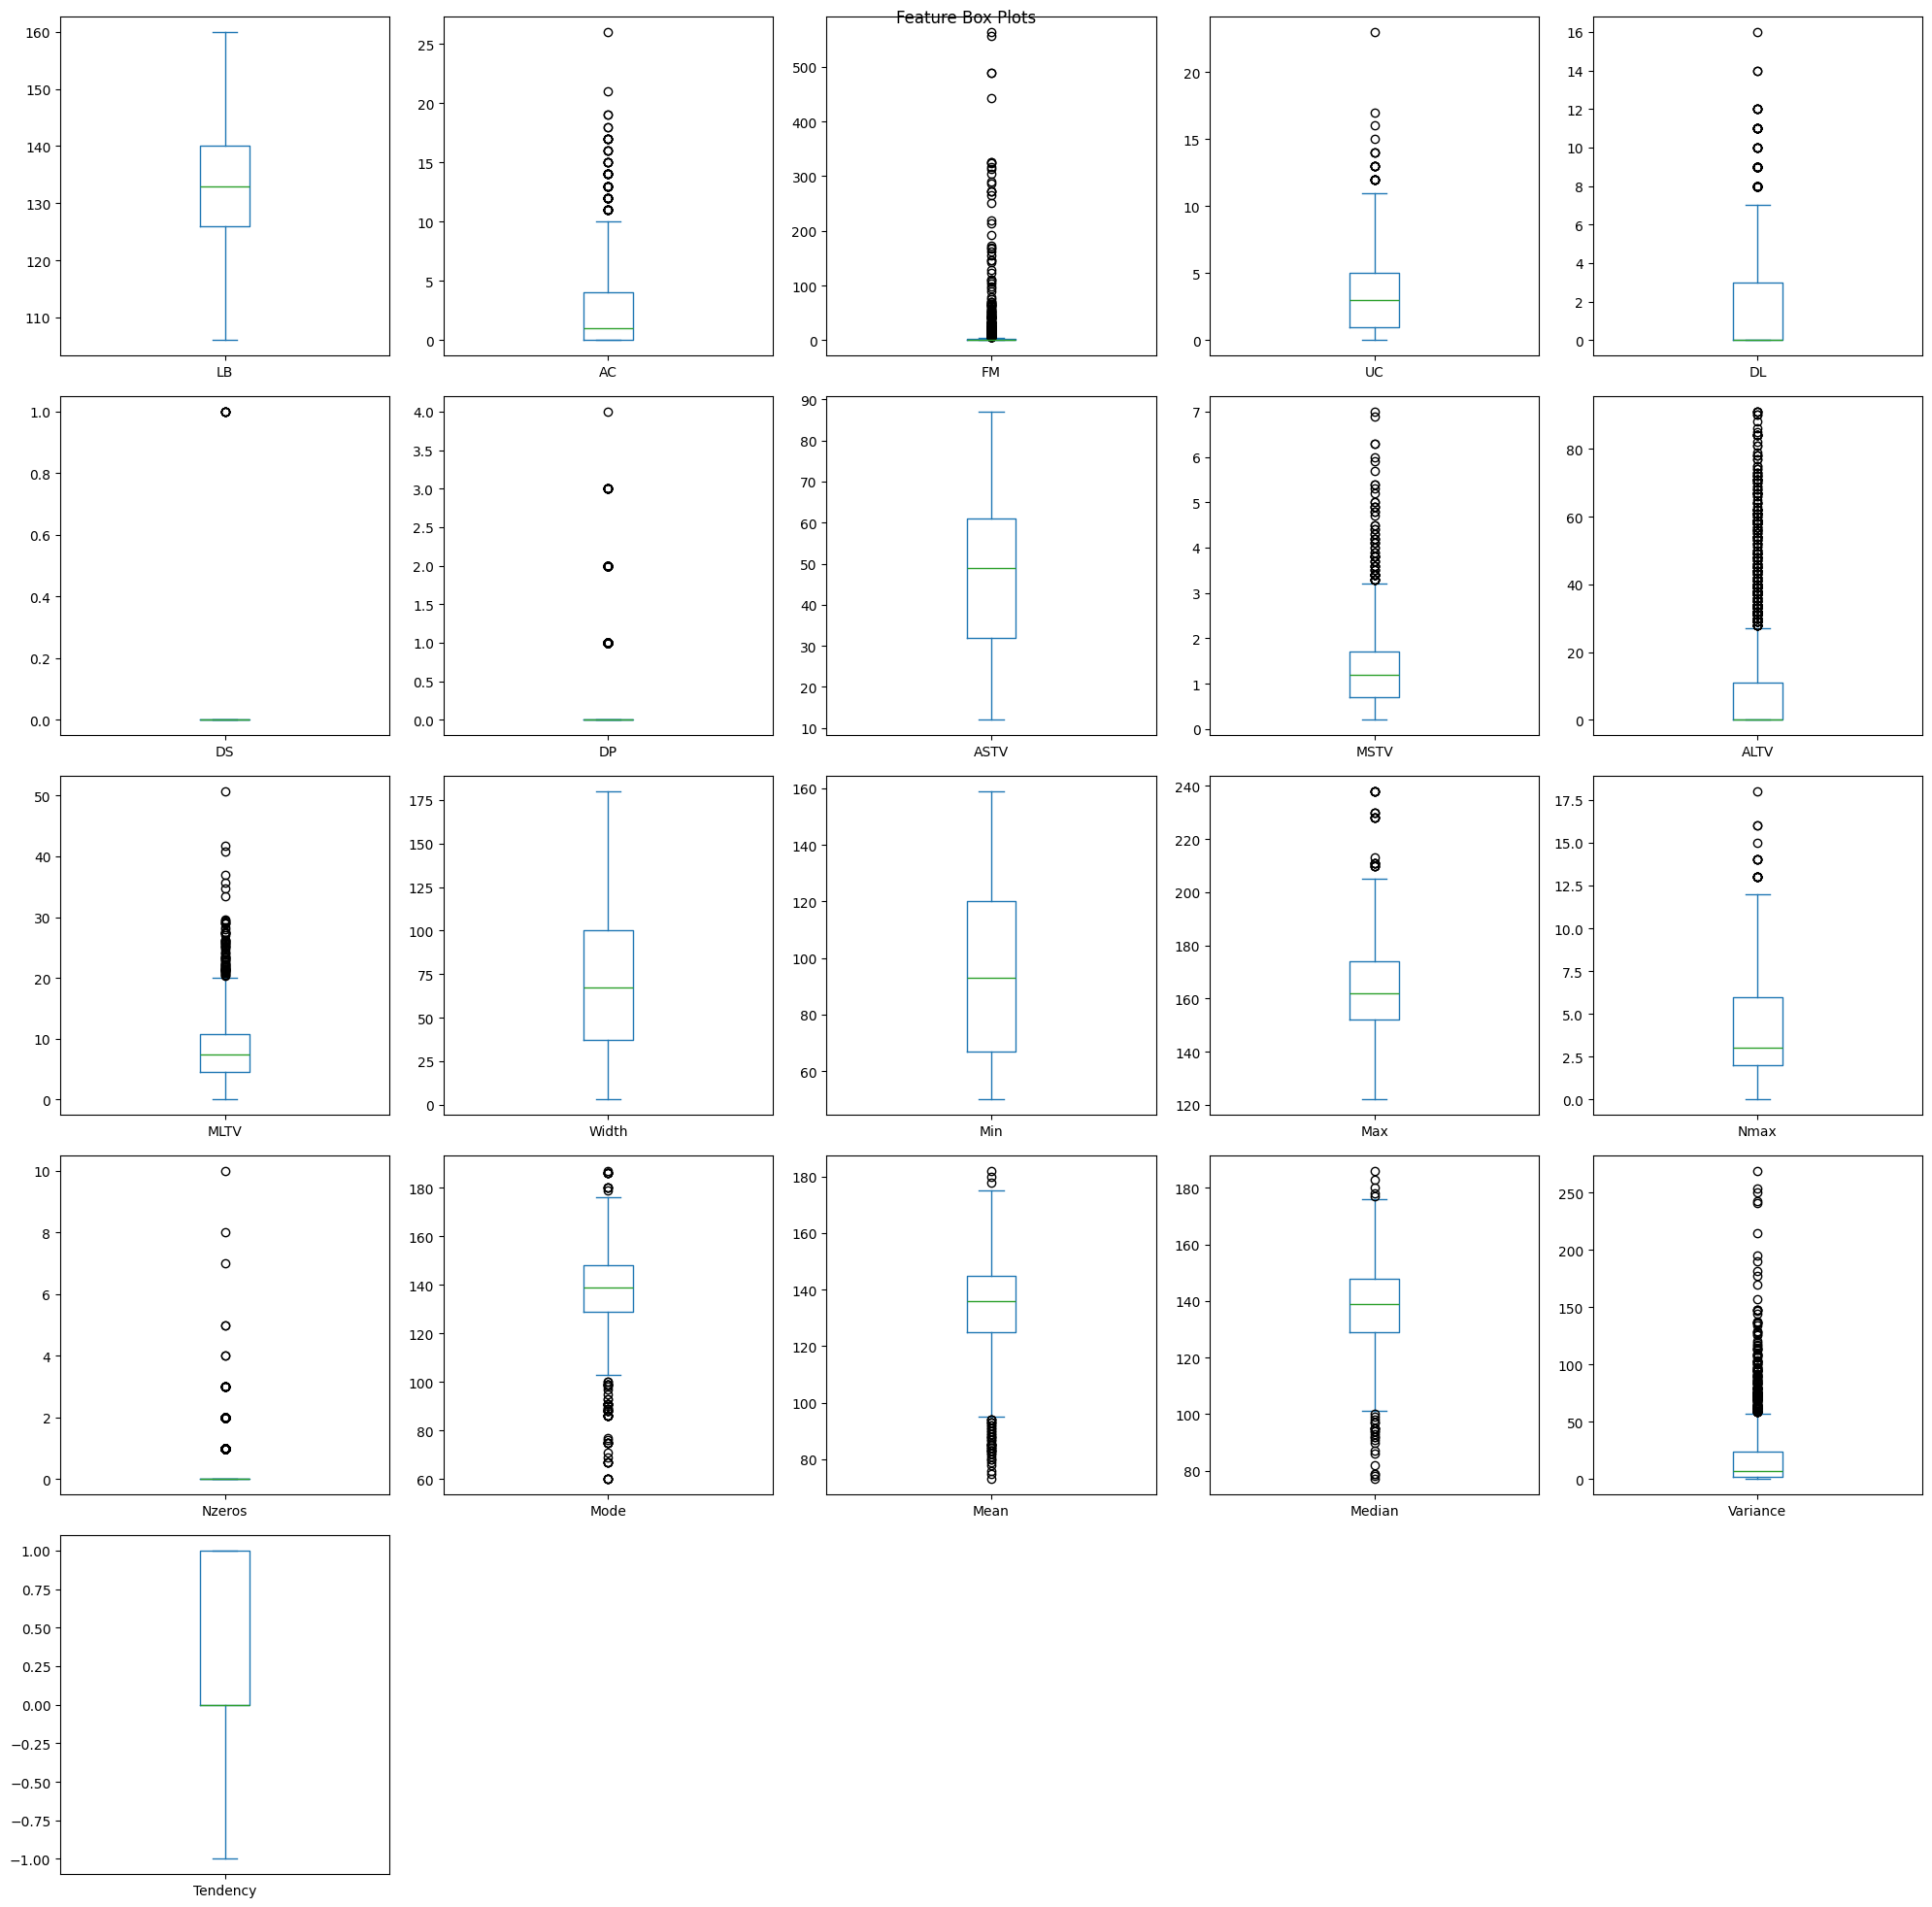

In [134]:
# Examine all 21 features in boxplots to detect outliers
# Define your 21 clinical features
features = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
    'ASTV', 'MSTV', 'ALTV', 'MLTV', 
    'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 
    'Mode', 'Mean', 'Median', 'Variance', 'Tendency'
]

# 2. Create X (ensure 'ctg' or 'df' is the name of your dataframe)
X = ctg[features] 

# 3. Now run your plot code
X.plot(kind='box', subplots=True, layout=(5,5), figsize=(20,20), title='Feature Box Plots')
plt.tight_layout()
plt.show()


As this is medical data, these outliers can not be removed as these oulliers are the ones that can detect abnormalities and clinical emergencies, so they will be left as is. 

LB is the baseline heart rate which looks clean and normal , because that is the normal fetal heart rate. Variance is showing many outliers, these outliers are the ones that show the pathelogical 3 state, hence they can be deleted.

ASTV box plot is very tall, this tells there is a wide range of variability in the babies heart rate.

Tendency box plot shows this shape because it have values that are -1,0,1



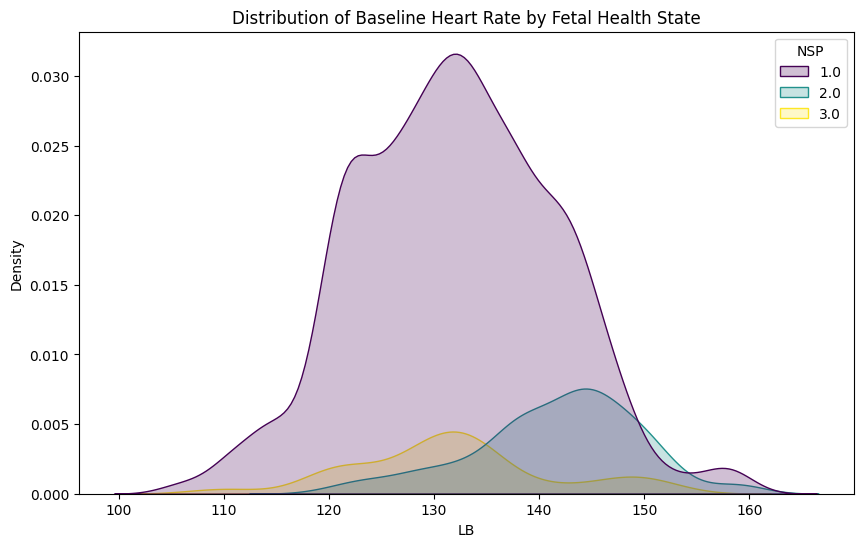

In [135]:
# Distribution of Baseline Heart Rate by Fetal Health State
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='LB', hue='NSP', fill=True, palette='viridis')
plt.title('Distribution of Baseline Heart Rate by Fetal Health State')
plt.show()


/var/folders/0q/hjy_4h2j4jzf1k_c5w04d4qc0000gn/T/ipykernel_66949/1791101260.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue='NSP', fill=True, common_norm=False, palette='Set2')


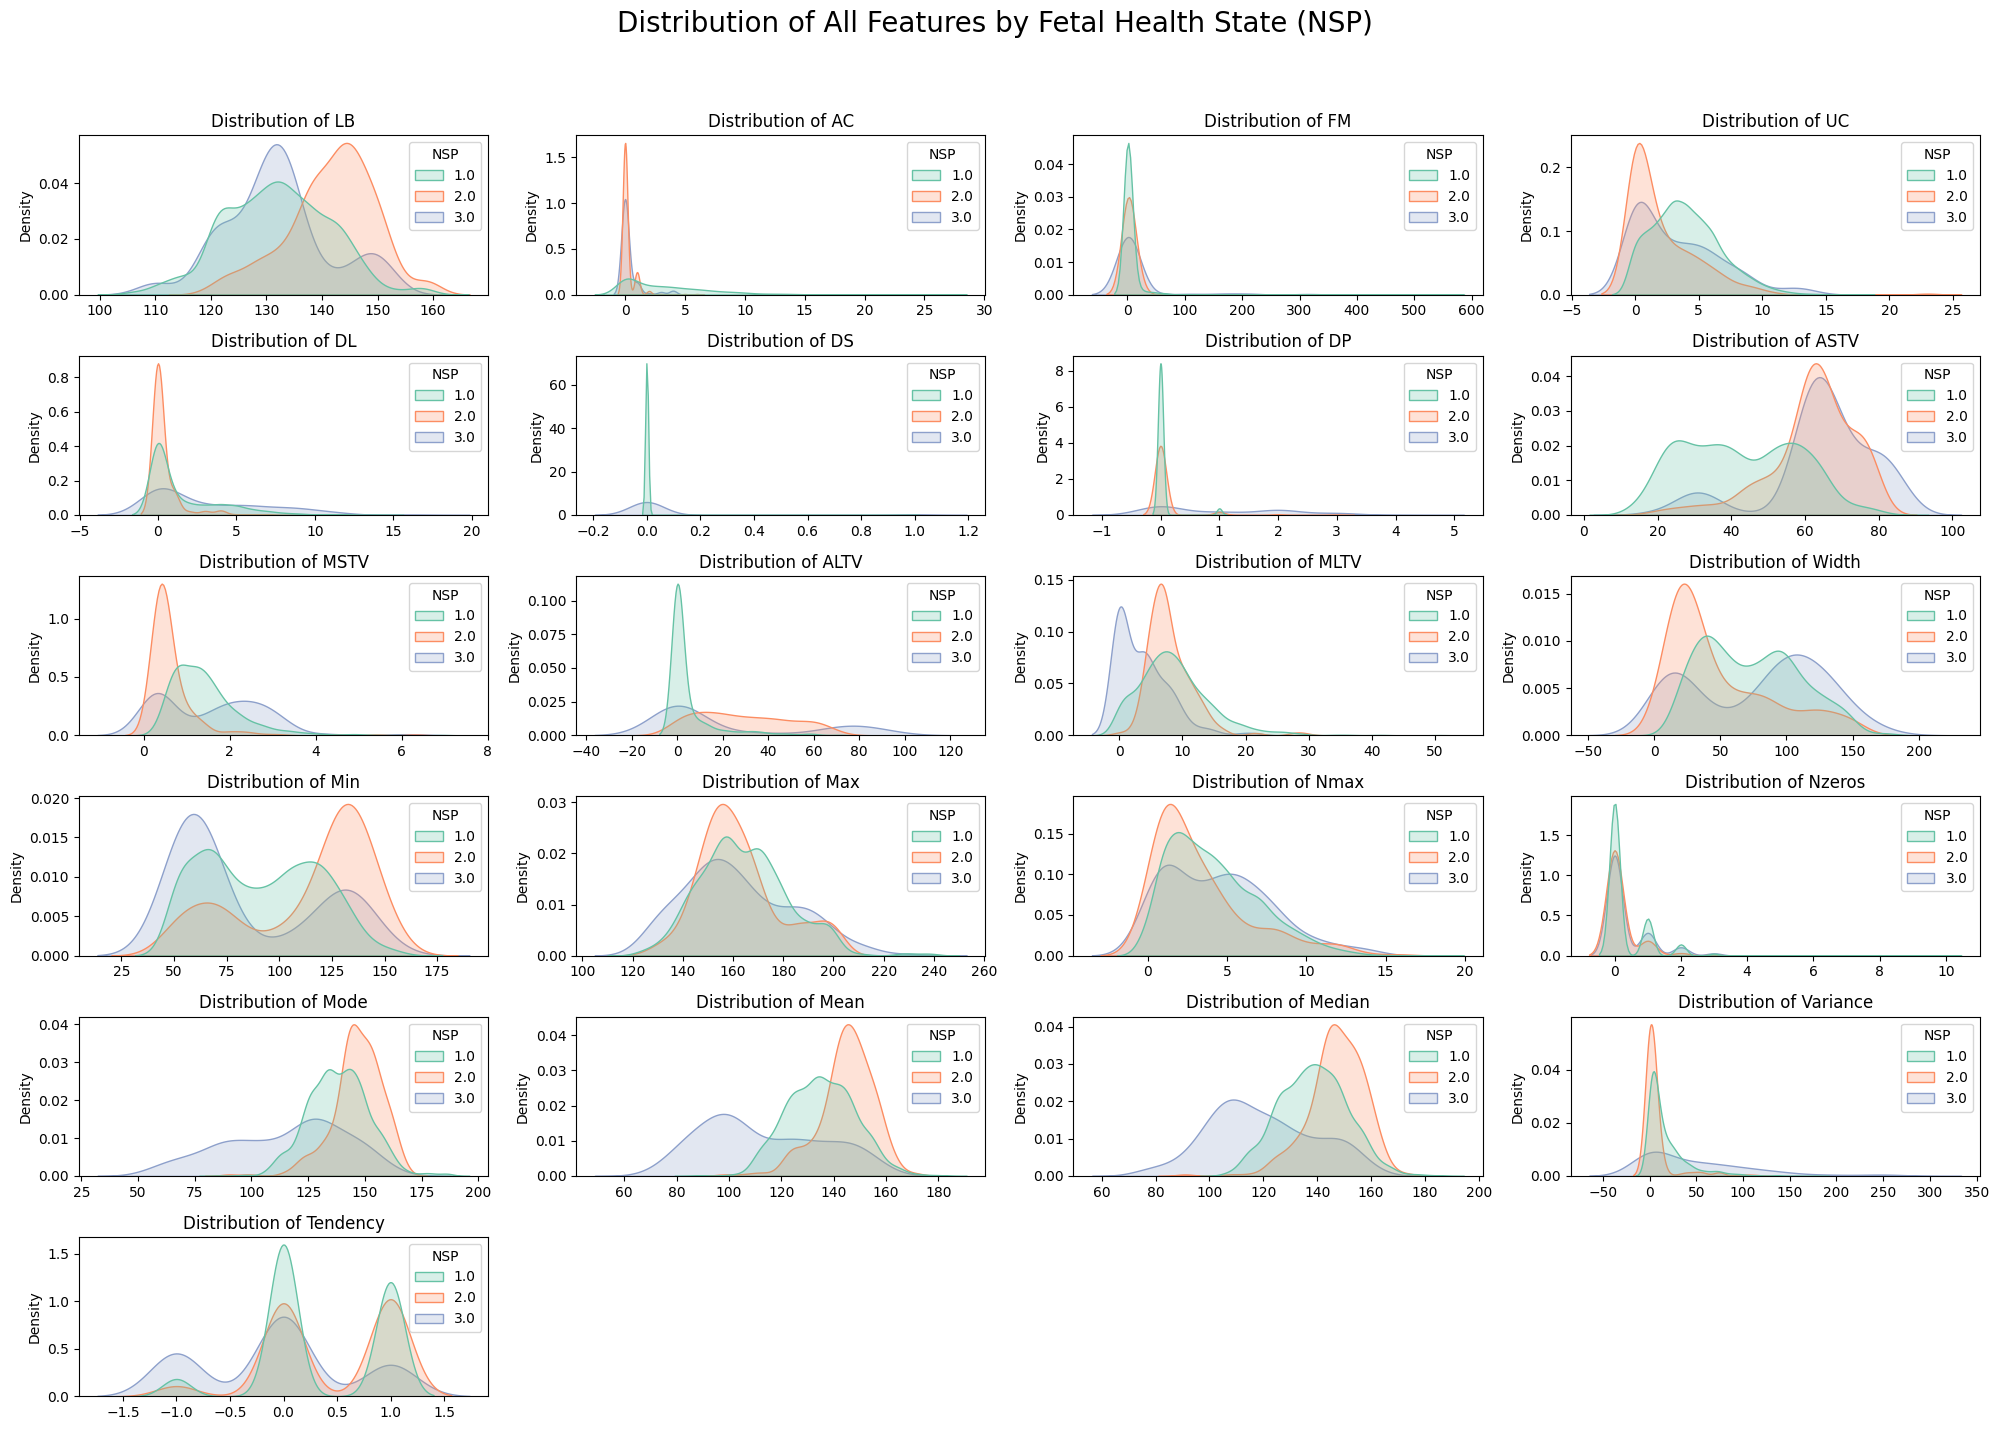

In [136]:
# Distribution of All Features by Fetal Health State
# Setting up the plotting area
plt.figure(figsize=(20, 15))
plt.suptitle('Distribution of All Features by Fetal Health State (NSP)', fontsize=20)

# 2. Loop through your 21 features and create a subplot for each
for i, column in enumerate(X.columns):
    plt.subplot(6, 4, i + 1)
    # hue='NSP' will color the lines differently for Normal, Suspect, and Pathologic
    sns.kdeplot(data=df, x=column, hue='NSP', fill=True, common_norm=False, palette='Set2')
    plt.title(f'Distribution of {column}')
    plt.xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Distribution of all features show that none of them have a perfect gaussian distribution and each feature has a certain level of skew to it whether its to the the right or left. 

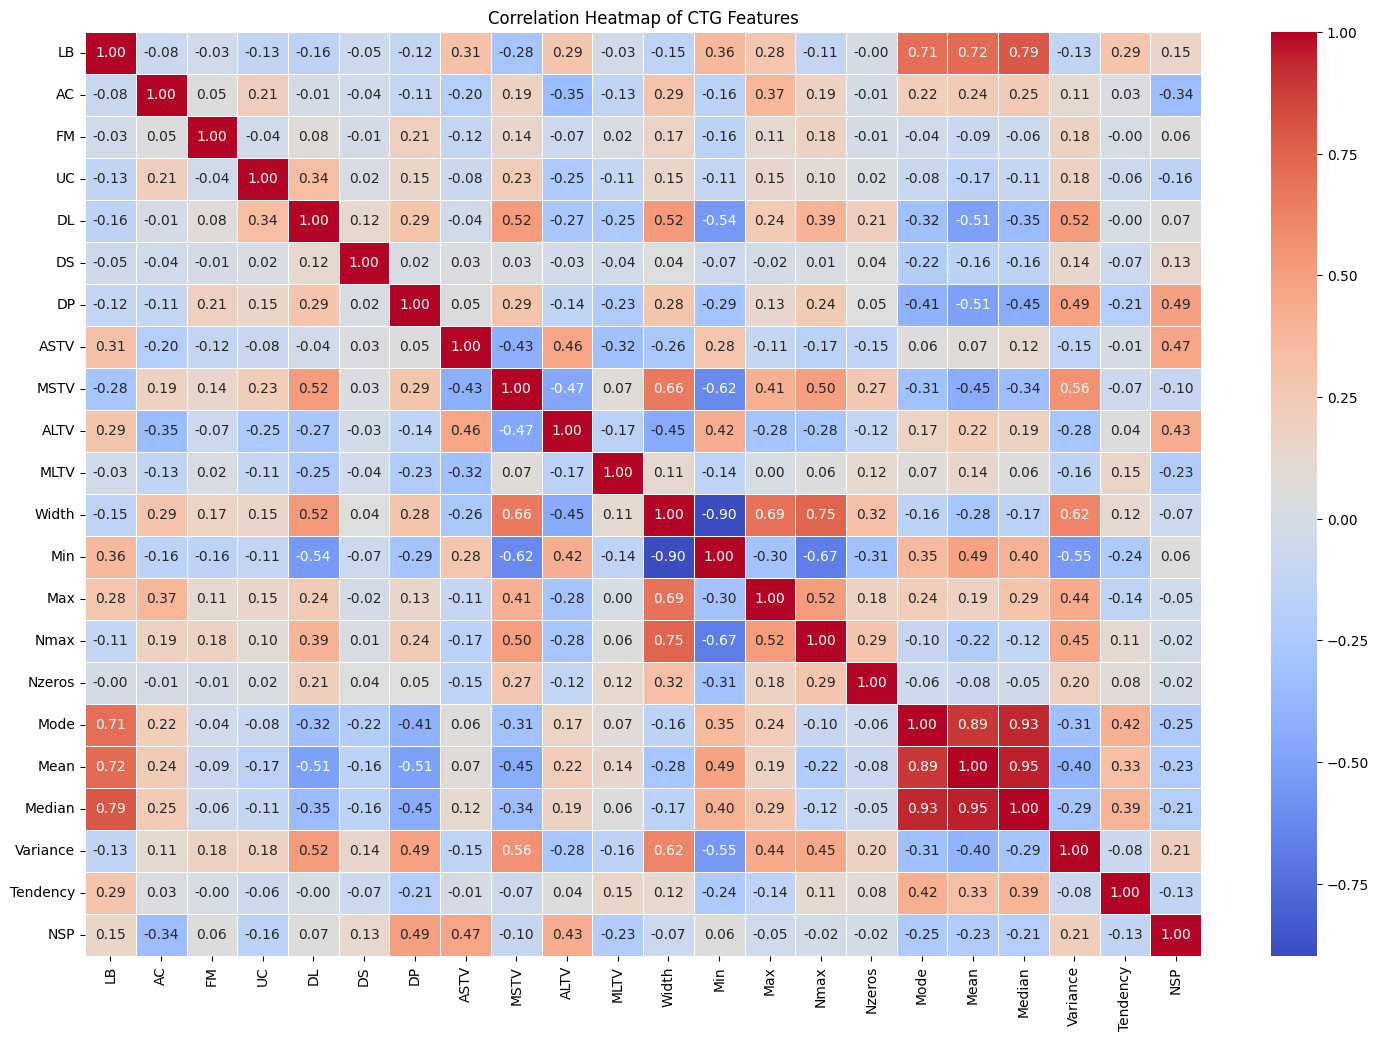

In [137]:
# Correlation Heatmap

# We include NSP to see how features correlate with the target
corr_matrix = ctg[features+['NSP']].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of CTG Features')
plt.show()


'ASTV','ALTV' and DP have the highest correlation with our target variable 'NSP' When these values go up the risk of pathological state increases significantly. Same with DP as that going up is a medical emergency, AC shows a negative correlation , means as accelerations go up the NSP value comes down. 

'Tendency','Variance','MSTV','DS','DL''FM' and 'LB" are independent variables 

Data is clean and ready to be split 

In [138]:
# Split the data, our target variable is 'NSP'

# Assign Y (Target) and X (Features)
y = ctg['NSP']
X = ctg.drop(['NSP'], axis=1)

# Split the data into Training (80%) and Testing (20%)

X_train80, X_test20, y_train80, y_test20 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train70, X_test30, y_train70, y_test30 = train_test_split(X, y, test_size=0.3, random_state=42)


print(f"80/20 Split - Train: {len(X_train80)}, Test: {len(X_test20)}")
print(f"70/30 Split - Train: {len(X_train70)}, Test: {len(X_test30)}")

print("X and Y are set, data is split!")

80/20 Split - Train: 1700, Test: 426
70/30 Split - Train: 1488, Test: 638
X and Y are set, data is split!


In [139]:
# Scaling the data for 80/20 split
scaler80 = StandardScaler()

# Fit only on training data, then transform both
X_train80_scaled = scaler80.fit_transform(X_train80)
X_test20_scaled = scaler80.transform(X_test20)


# Scaling the data for 70/30 split
scaler70 = StandardScaler()

X_train70_scaled = scaler70.fit_transform(X_train70)
X_test30_scaled = scaler70.transform(X_test30)


print("X and Y are set and scaling is complete!")

X and Y are set and scaling is complete!


In [140]:
# Logistic Regression 80/20 split

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train80_scaled, y_train80)
lr_pred = lr_model.predict(X_test20_scaled)

print("--- Logistic Regression 80/20 split ---")
print(classification_report(y_test20, lr_pred))


--- Logistic Regression 80/20 split ---
              precision    recall  f1-score   support

         1.0       0.94      0.94      0.94       333
         2.0       0.63      0.59      0.61        64
         3.0       0.65      0.76      0.70        29

    accuracy                           0.87       426
   macro avg       0.74      0.76      0.75       426
weighted avg       0.87      0.87      0.87       426



In [141]:
# Neighbors Classifier 80/20 split

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train80_scaled, y_train80)
knn_pred = knn_model.predict(X_test20_scaled)

print("--- K-Nearest Neighbors  80/20 split ---")
print(classification_report(y_test20, knn_pred))


--- K-Nearest Neighbors  80/20 split ---
              precision    recall  f1-score   support

         1.0       0.94      0.97      0.96       333
         2.0       0.78      0.67      0.72        64
         3.0       0.82      0.79      0.81        29

    accuracy                           0.92       426
   macro avg       0.85      0.81      0.83       426
weighted avg       0.91      0.92      0.91       426



In [142]:
# Random Forest Classifier 80/20 split

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train80_scaled, y_train80)
rf_pred = rf_model.predict(X_test20_scaled)

print("--- Random Forest ---")
print(classification_report(y_test20, rf_pred))



--- Random Forest ---
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.84      0.77      0.80        64
         3.0       0.96      0.93      0.95        29

    accuracy                           0.94       426
   macro avg       0.92      0.89      0.91       426
weighted avg       0.94      0.94      0.94       426



In [143]:
# SVC 80/20 split

svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train80_scaled, y_train80)
svm_pred = svm_model.predict(X_test20_scaled)

print("--- SVC 80/20 split---")
print(classification_report(y_test20, svm_pred))


--- SVC 80/20 split---
              precision    recall  f1-score   support

         1.0       0.99      0.87      0.93       333
         2.0       0.58      0.89      0.70        64
         3.0       0.74      0.90      0.81        29

    accuracy                           0.88       426
   macro avg       0.77      0.89      0.82       426
weighted avg       0.91      0.88      0.89       426



In [144]:
# Logistic Regression 70/30 split

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train70_scaled, y_train70)
lr_pred = lr_model.predict(X_test30_scaled)

print("--- Logistic Regression 70/30 split ---")
print(classification_report(y_test30, lr_pred))

--- Logistic Regression 70/30 split ---
              precision    recall  f1-score   support

         1.0       0.95      0.94      0.95       496
         2.0       0.69      0.62      0.66       101
         3.0       0.64      0.85      0.73        41

    accuracy                           0.89       638
   macro avg       0.76      0.81      0.78       638
weighted avg       0.89      0.89      0.89       638



In [145]:
# Neighbors Classifier 70/30 split

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train70_scaled, y_train70)
knn_pred = knn_model.predict(X_test30_scaled)

print("--- K-Nearest Neighbors  70/30 split ---")
print(classification_report(y_test30, knn_pred))

--- K-Nearest Neighbors  70/30 split ---
              precision    recall  f1-score   support

         1.0       0.94      0.97      0.95       496
         2.0       0.77      0.70      0.74       101
         3.0       0.84      0.76      0.79        41

    accuracy                           0.91       638
   macro avg       0.85      0.81      0.83       638
weighted avg       0.91      0.91      0.91       638



In [146]:
# Random Forest Classifier 70/30 split

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train70_scaled, y_train70)
rf_pred = rf_model.predict(X_test30_scaled)

print("--- Random Forest 70/30 split ---")
print(classification_report(y_test30, rf_pred))

--- Random Forest 70/30 split ---
              precision    recall  f1-score   support

         1.0       0.95      0.98      0.97       496
         2.0       0.88      0.75      0.81       101
         3.0       0.93      0.93      0.93        41

    accuracy                           0.94       638
   macro avg       0.92      0.89      0.90       638
weighted avg       0.94      0.94      0.94       638



In [147]:
 #SVC 80/20 split 70/30 split

svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train70_scaled, y_train70)
svm_pred = svm_model.predict(X_test30_scaled)

print("--- SVC 70/30 split---")
print(classification_report(y_test30, svm_pred))


--- SVC 70/30 split---
              precision    recall  f1-score   support

         1.0       0.98      0.85      0.91       496
         2.0       0.56      0.84      0.67       101
         3.0       0.65      0.88      0.75        41

    accuracy                           0.85       638
   macro avg       0.73      0.86      0.78       638
weighted avg       0.89      0.85      0.86       638



--- Model Comparison Table (80/20 Split) ---


,Model,Accuracy,Pathologic Recall,Pathologic Precision,Normal F1-Score
0,Random Forest,0.94,0.93,0.96,0.97
1,K-Nearest Neighbors,0.92,0.79,0.82,0.96
2,SVC (SVM),0.88,0.90,0.74,0.93
3,Logistic Regression,0.87,0.76,0.65,0.94


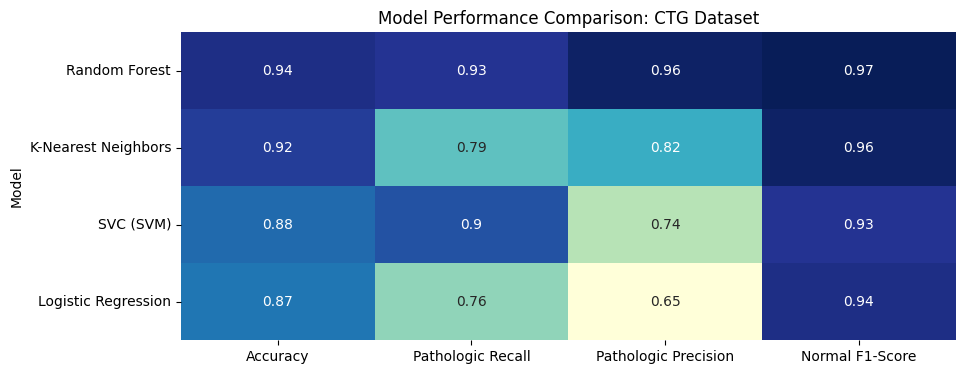

In [148]:

#  Create the data based on your 80/20 split results
data = {
    'Model': ['Random Forest', 'K-Nearest Neighbors', 'SVC (SVM)', 'Logistic Regression'],
    'Accuracy': [0.94, 0.92, 0.88, 0.87],
    'Pathologic Recall': [0.93, 0.79, 0.90, 0.76],
    'Pathologic Precision': [0.96, 0.82, 0.74, 0.65],
    'Normal F1-Score': [0.97, 0.96, 0.93, 0.94]
}

# 2. Convert to a DataFrame
comparison_df = pd.DataFrame(data)

# 3. Sort by Accuracy so the winner is at the top
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

# 4. Display the table in your notebook
print("--- Model Comparison Table (80/20 Split) ---")
display(comparison_df)

# 5. Visual Version (Heatmap Style) 
# This makes it very easy to see the "winners" in green
plt.figure(figsize=(10, 4))
sns.heatmap(comparison_df.set_index('Model'), annot=True, cmap='YlGnBu', cbar=False)
plt.title('Model Performance Comparison: CTG Dataset')
plt.show()


--- Model Comparison Table (70/30 Split) ---


,Model,Accuracy,Pathologic Recall,Pathologic Precision,Normal F1-Score
0,Random Forest,0.94,0.93,0.93,0.97
1,K-Nearest Neighbors,0.91,0.76,0.84,0.95
3,Logistic Regression,0.89,0.85,0.64,0.95
2,SVC (SVM),0.85,0.88,0.65,0.91


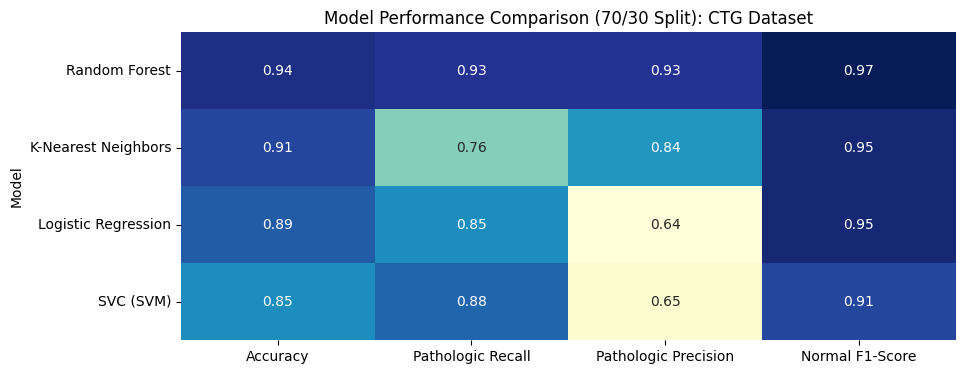

In [149]:
#  Data based on your 70/30 split results
data_7030 = {
    'Model': ['Random Forest', 'K-Nearest Neighbors', 'SVC (SVM)', 'Logistic Regression'],
    'Accuracy': [0.94, 0.91, 0.85, 0.89],
    'Pathologic Recall': [0.93, 0.76, 0.88, 0.85],
    'Pathologic Precision': [0.93, 0.84, 0.65, 0.64],
    'Normal F1-Score': [0.97, 0.95, 0.91, 0.95]
}

# Create and sort DataFrame
comparison_7030_df = pd.DataFrame(data_7030)
comparison_7030_df = comparison_7030_df.sort_values(by='Accuracy', ascending=False)

# Display the Table
print("--- Model Comparison Table (70/30 Split) ---")
display(comparison_7030_df)

# Create the Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(comparison_7030_df.set_index('Model'), annot=True, cmap='YlGnBu', cbar=False)
plt.title('Model Performance Comparison (70/30 Split): CTG Dataset')
plt.show()


If we compare all the models and also the data an test split 80/20 vs 70/30 the random forest model performs the best with the 80/20 split

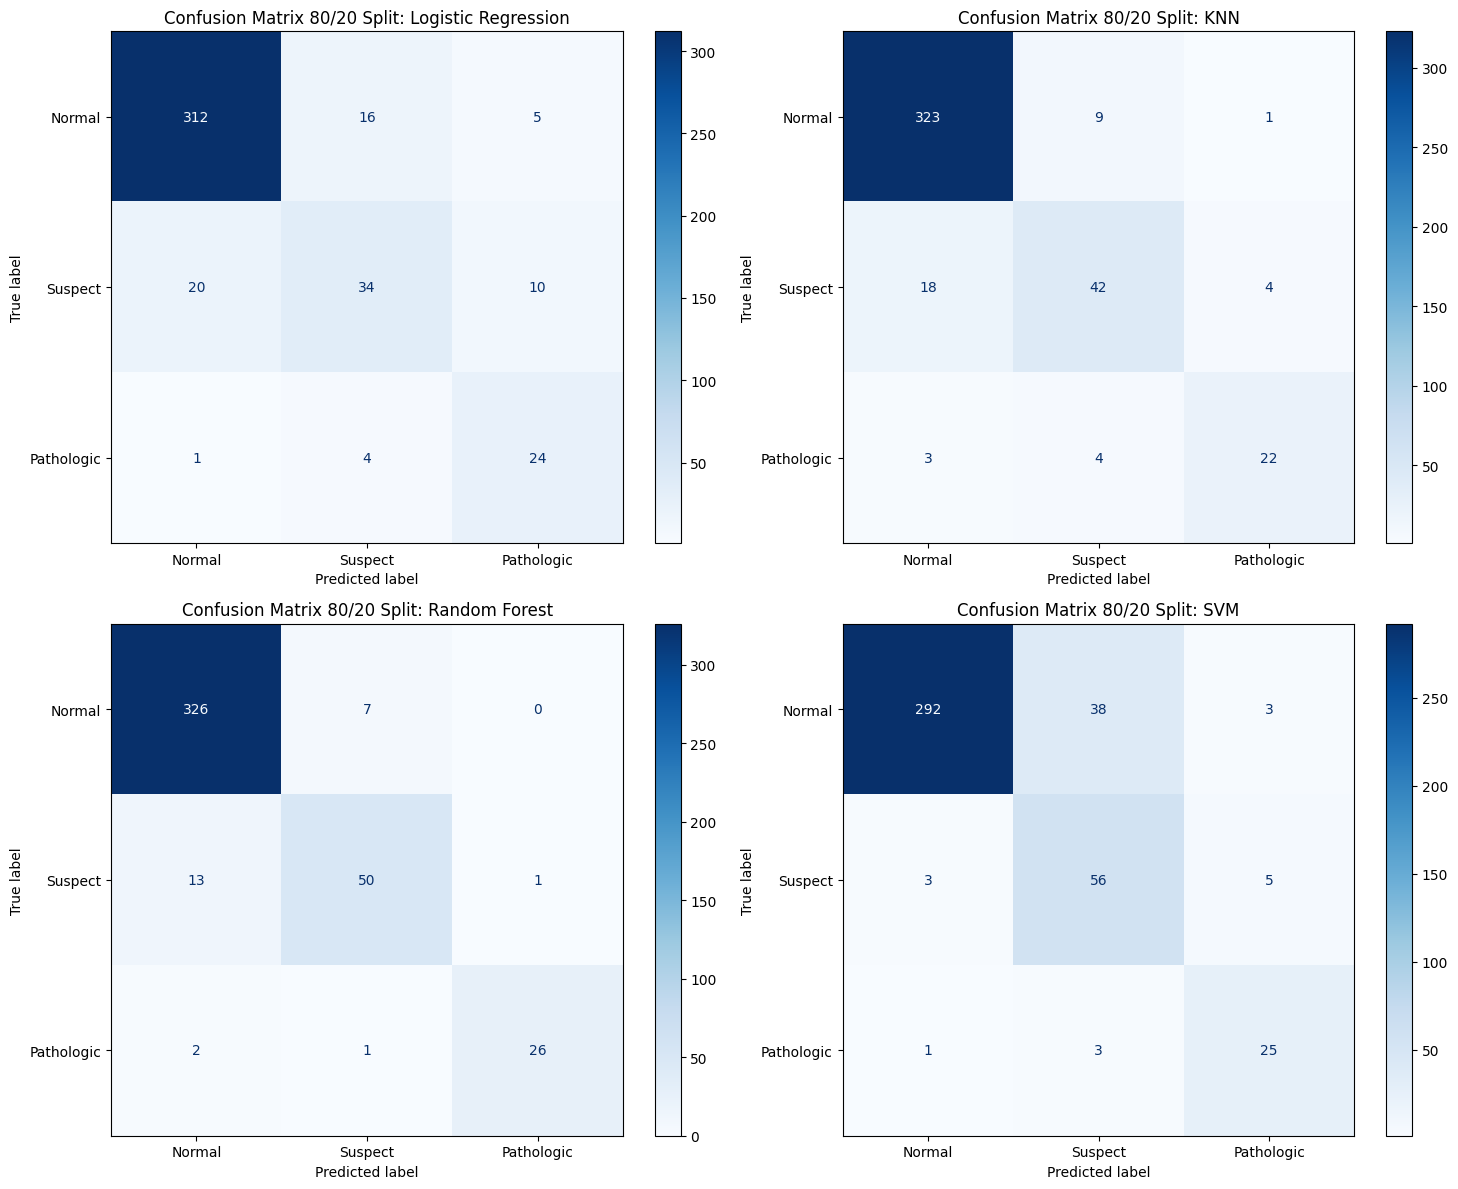

In [150]:
# Confusion Matrices

# List of models and their names for the loop
model_list = [
    (lr_model, "Logistic Regression"),
    (knn_model, "KNN"),
    (rf_model, "Random Forest"),
    (svm_model, "SVM")
]

# Create a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (model, name) in enumerate(model_list):
    # Get predictions
    y_pred = model.predict(X_test20_scaled)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test20, y_pred)
    
    # Plot using ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Suspect', 'Pathologic'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix 80/20 Split: {name}')

plt.tight_layout()
plt.show()


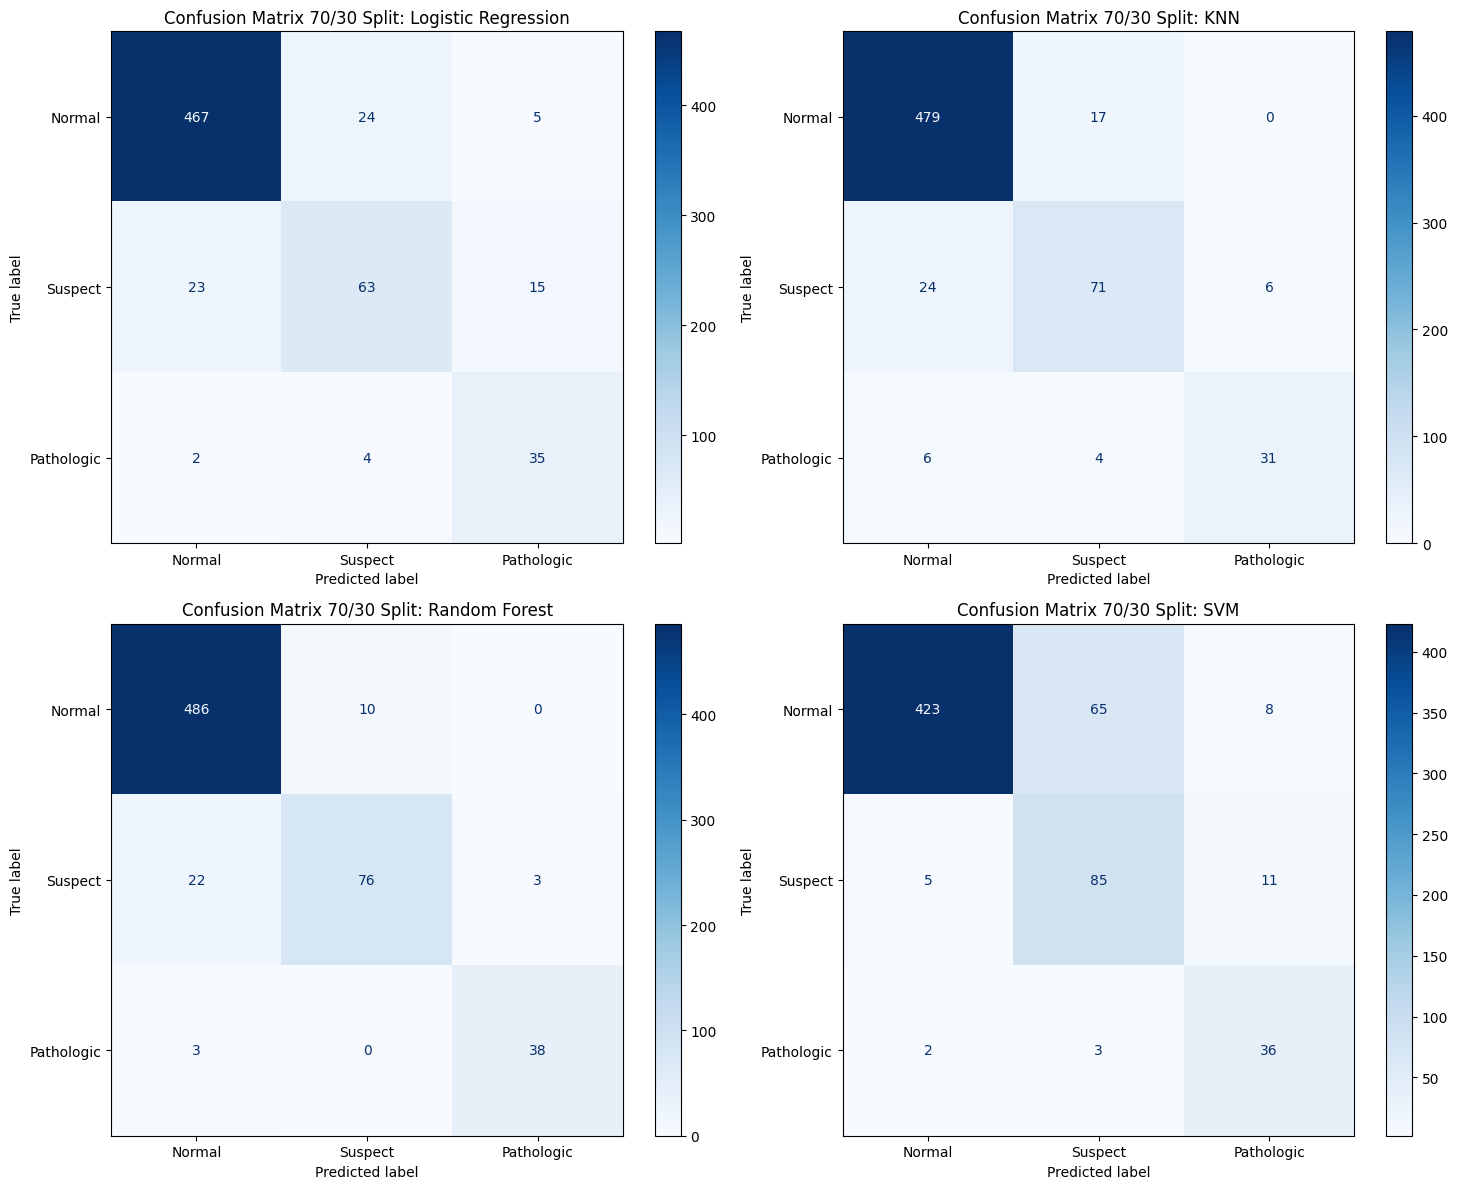

In [151]:
# Confusion Matrices 70/30 split

# List of models and their names for the loop
model_list_70 = [
    (lr_model, "Logistic Regression"),
    (knn_model, "KNN"),
    (rf_model, "Random Forest"),
    (svm_model, "SVM")
]

# Create a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (model, name) in enumerate(model_list_70):
    # Get predictions
    y_pred = model.predict(X_test30_scaled)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test30, y_pred)
    
    # Plot using ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Suspect', 'Pathologic'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix 70/30 Split: {name}')

plt.tight_layout()
plt.show()


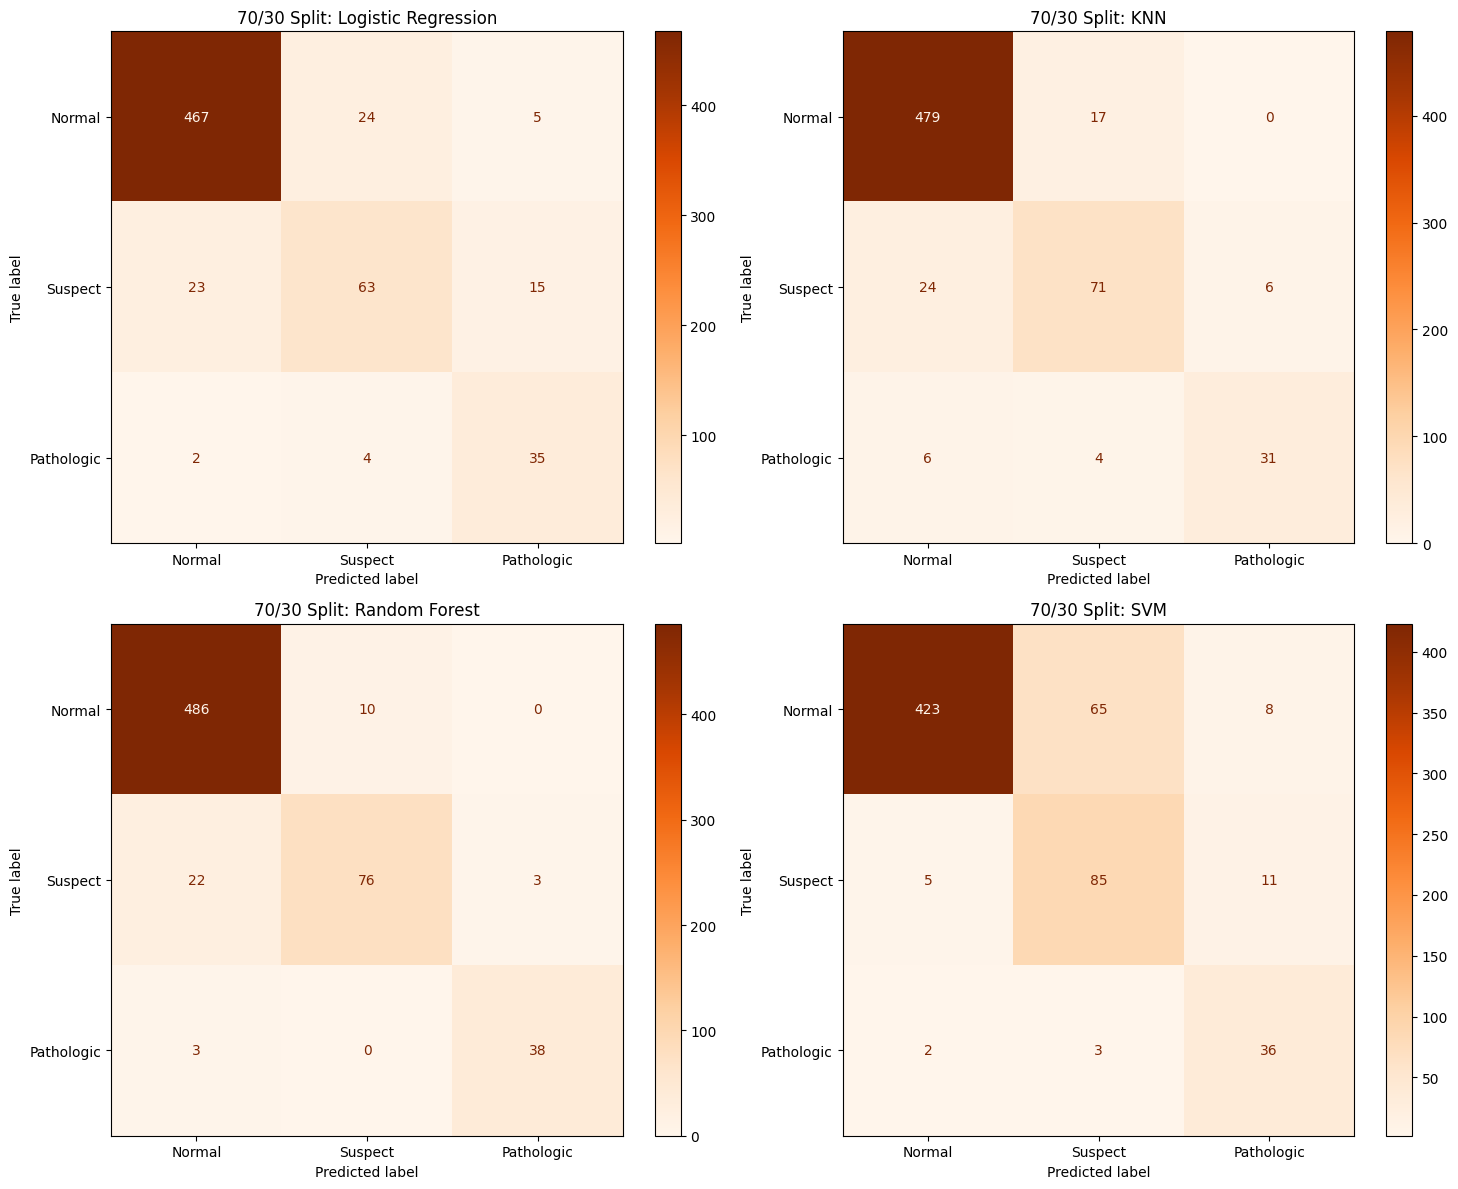

In [152]:

# List of models using your 70/30 test data
model_list_70 = [
    (lr_model, "Logistic Regression"),
    (knn_model, "KNN"),
    (rf_model, "Random Forest"),
    (svm_model, "SVM")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (model, name) in enumerate(model_list_70):
    # Important: Use the 30% test set here
    y_pred = model.predict(X_test30_scaled)
    cm = confusion_matrix(y_test30, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Suspect', 'Pathologic'])
    disp.plot(ax=axes[i], cmap='Oranges', values_format='d')
    axes[i].set_title(f'70/30 Split: {name}')

plt.tight_layout()
plt.show()

Random forest identified 326 out of 333 Normal babies, the highest of all models, and it predicted 0 healthy babies as Pathologic meaning it doesnt cause a major false alarm. It caught 26 of the 29 Pathologic cases. 

80/20 Split shows better results are better than 70/30 , although in some cases 70/30 has performed better.

In [153]:
import json
from sklearn.metrics import classification_report

# Re-generate predictions for the 80/20 test set
# Training model is Random Forest
winning_predictions = rf_model.predict(X_test20_scaled)

# Generate the report dictionary
report_dict = classification_report(y_test20, winning_predictions, output_dict=True)

# 3. Save to JSON
with open('classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=4)

print("Success! The lengths matched and the JSON report is saved.")


Success! The lengths matched and the JSON report is saved.


Following has been taken purely from chatgpt

In [154]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X is your original 21 features


In [155]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Initialize Stratified K-Fold (Correct parameter is n_splits)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 2. Run Cross-Validation
# Note: Use the full scaled X and full y here
cv_results = cross_val_score(rf_model, X_scaled, y, cv=skf, scoring='accuracy')

# 3. Report Results
print(f"Scores for each fold: \n{cv_results}")
print(f"\nAverage Accuracy: {cv_results.mean():.4f}")
print(f"Standard Deviation: {cv_results.std():.4f}")


Scores for each fold: 
[0.95305164 0.9342723  0.9342723  0.94835681 0.94835681 0.95774648
 0.9245283  0.92924528 0.94811321 0.96698113]

Average Accuracy: 0.9445
Standard Deviation: 0.0128


10-Fold is the "Gold Standard":By testing the model 10 different times on 10 different "slices" of the data, you are proving that your 94% accuracy isn't just a "lucky" split. If your Standard Deviation is low, it means the model is ready for the real world.

Accuracy is 94.45%, which shows the repetitivness of model. 



In [156]:
# Use the 80/20 test set (X_test20)
sample_patient = X_test20.iloc[[10]] 
true_health_state = y_test20.iloc[10]

# Use the scaler created for the 80/20 split
sample_scaled = scaler80.transform(sample_patient)

# Prediction
prediction = rf_model.predict(sample_scaled)

print(f"--- Individual Test Case ---")
print(f"Model Prediction: {prediction[0]}")
print(f"Actual Clinical State: {true_health_state}")


--- Individual Test Case ---
Model Prediction: 1.0
Actual Clinical State: 1.0


In [157]:
# Find the first 'Pathologic' case in the test set
pathologic_indices = y_test20[y_test20 == 3.0].index
target_index = pathologic_indices[0] # Get the first one

# Grab that specific patient
path_patient = X_test20.loc[[target_index]]
path_true = y_test20.loc[target_index]

# Scale and Predict
path_scaled = scaler80.transform(path_patient)
path_pred = rf_model.predict(path_scaled)

print(f"--- Emergency Test Case ---")
print(f"Model Prediction: {path_pred}")
print(f"Actual Clinical State: {path_true}")


--- Emergency Test Case ---
Model Prediction: [3.]
Actual Clinical State: 3.0


In [165]:

# Save the best model using joblib to use for future predictions
import joblib

joblib.dump(rf_model, 'rf_best_model.pkl')

print("Model saved successfully as rf_best_model.pkl!")


Model saved successfully as rf_best_model.pkl!


In [163]:
import joblib

# 1. Load the saved model into memory
loaded_model = joblib.load('rf_best_model.pkl')

# 2. Make predictions on your scaled test data
# Use your scaled test set (e.g., X_test20_scaled)
new_predictions = loaded_model.predict(X_test20_scaled)

# 3. Check the first few predictions
print(f"First 5 predictions from loaded model: {new_predictions[:5]}")


First 5 predictions from loaded model: [1. 1. 1. 1. 1.]


In [166]:
# Compare the loaded model's first 100 predictions with your 'best_rf_model'
original_preds = rf_model.predict(X_test20_scaled[:100])
loaded_preds = loaded_model.predict(X_test20_scaled[:100])

# Check if they are exactly the same
if (original_preds == loaded_preds).all():
    print("✅ Success! The loaded model is an exact match of the trained version.")
else:
    print("❌ Warning: There is a mismatch between the models.")


✅ Success! The loaded model is an exact match of the trained version.


In [167]:
import joblib
joblib.dump(scaler80, 'ctg_scaler.pkl') 
print("Model saved successfully as ctg_scaler.pkl!")

Model saved successfully as ctg_scaler.pkl!


In [170]:
X_train80.head()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
1234,125.0,0.0,0.0,4.0,32.0,1.1,3.0,13.0,0.0,0.0,0.0,51.0,96.0,147.0,4.0,0.0,126.0,125.0,127.0,2.0,0.0
481,140.0,0.0,0.0,1.0,60.0,0.8,32.0,11.2,0.0,0.0,0.0,120.0,79.0,199.0,9.0,0.0,141.0,141.0,142.0,3.0,0.0
1112,122.0,0.0,0.0,0.0,20.0,1.8,0.0,13.8,1.0,0.0,0.0,39.0,103.0,142.0,1.0,0.0,120.0,119.0,121.0,3.0,0.0
1304,137.0,3.0,0.0,3.0,36.0,0.9,0.0,5.0,1.0,0.0,0.0,63.0,115.0,178.0,4.0,0.0,148.0,148.0,149.0,9.0,0.0
862,142.0,2.0,0.0,3.0,46.0,0.7,27.0,5.9,0.0,0.0,0.0,26.0,133.0,159.0,1.0,0.0,150.0,148.0,150.0,1.0,0.0


In [171]:
print(X_train80.columns.tolist())

['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']


In [196]:
# for requirements txt

print ("numpy version: " + np.__version__)
print ("pandas version: " + pd.__version__)
print ("seaborn version: " + sns.__version__)
print ("joblib version: " + joblib.__version__)
print("scikit-learn version: " + sklearn.__version__)
print("matplotlib version: " + matplotlib.__version__)
print("streamlit version: " + st.__version__)


numpy version: 2.4.4
pandas version: 3.0.2
seaborn version: 0.13.2
joblib version: 1.5.3
scikit-learn version: 1.8.0
matplotlib version: 3.10.9
streamlit version: 1.57.0


In [197]:
%%writefile requirements.txt
numpy version: 2.4.4
pandas version: 3.0.2
seaborn version: 0.13.2
joblib version: 1.5.3
scikit-learn version: 1.8.0
matplotlib version: 3.10.9
streamlit version: 1.57.0

Overwriting requirements.txt
